# Project 8
# Job Market Analysis and Recommendation System

# Phase 1: Data Preparation & Cleaning (Excel ingestion, column normalization, missing value handling)

In [6]:
# Step 1 (libraries)
# Data handling
import pandas as pd        # data loading & manipulation
import numpy as np         # numerical operations

# Visualization
import matplotlib.pyplot as plt   # basic plotting
import seaborn as sns             # statistical visualizations
import plotly.express as px       # interactive charts/maps

# NLP preprocessing
import re                         # regex for text cleaning
import nltk                       # stopwords, tokenization, lemmatization
from nltk.corpus import stopwords # stopword removal
from nltk.stem import WordNetLemmatizer # lemmatization

# Machine Learning
from sklearn.model_selection import train_test_split   # split data
from sklearn.feature_extraction.text import TfidfVectorizer # text vectorization
from sklearn.metrics import confusion_matrix, classification_report # evaluation
from sklearn.linear_model import LogisticRegression    # baseline model
from sklearn.ensemble import RandomForestClassifier    # advanced model
import xgboost as xgb                                  # gradient boosting

# Deep Learning / NLP
import tensorflow as tf                                # neural networks
from tensorflow import keras                           # deep learning models
from sentence_transformers import SentenceTransformer  # transformer embeddings

# Time-Series Forecasting
from prophet import Prophet                            # demand forecasting
from statsmodels.tsa.arima.model import ARIMA          # time-series model

In [10]:
# Step 2: Load dataset and inspect
file_path = "/content/all_upwork_jobs_2024-02-07-2024-03-24.xlsx"
df = pd.read_excel(file_path)

# Quick inspection
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())

# Preview first few rows
df.head()

Shape of dataset: (244828, 8)

Column names:
 Index(['title', 'link', 'published_date', 'is_hourly', 'hourly_low',
       'hourly_high', 'budget', 'country'],
      dtype='object')

Missing values:
 title                  1
link                   1
published_date         0
is_hourly              0
hourly_low        142406
hourly_high       146053
budget            140937
country             5077
dtype: int64


,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States
3,Talent Hunter Specialized in Marketing,https://www.upwork.com/jobs/Talent-Hunter-Spec...,2024-02-17 09:08:08+00:00,True,NaN,NaN,NaN,United States
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India


In [11]:
# Step 3: Data Cleaning & Preprocessing

# 1. Handle missing values
# Drop rows with missing critical info (title or link)
df = df.dropna(subset=['title', 'link'])

# Fill missing numeric values with 0 (to mark unavailable)
df['hourly_low'] = df['hourly_low'].fillna(0)
df['hourly_high'] = df['hourly_high'].fillna(0)
df['budget'] = df['budget'].fillna(0)

# Fill missing country with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# 2. Apply business logic
# Hourly jobs: keep hourly_low & hourly_high
# Budget jobs: keep budget
df['job_type'] = df['is_hourly'].apply(lambda x: 'Hourly' if x else 'Budget')

# 3. Text preprocessing for NLP
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'[^a-z\s]', '', text)             # remove special chars/numbers
    tokens = text.split()                            # tokenize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words] # lemmatize & remove stopwords
    return " ".join(tokens)

df['clean_title'] = df['title'].apply(clean_text)

# Quick check
df[['title','clean_title','job_type','hourly_low','hourly_high','budget','country']].head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,title,clean_title,job_type,hourly_low,hourly_high,budget,country
0,Experienced Media Buyer For Solar Pannel and R...,experienced medium buyer solar pannel roofing ...,Budget,0.0,0.0,500.0,Unknown
1,Full Stack Developer,full stack developer,Budget,0.0,0.0,1100.0,United States
2,SMMA Bubble App,smma bubble app,Hourly,10.0,30.0,0.0,United States
3,Talent Hunter Specialized in Marketing,talent hunter specialized marketing,Hourly,0.0,0.0,0.0,United States
4,Data Engineer,data engineer,Budget,0.0,0.0,650.0,India
5,SEO for Portuguese Psychologist site,seo portuguese psychologist site,Hourly,0.0,0.0,0.0,Portugal
6,Want to fix the WordPress Plugin,want fix wordpress plugin,Budget,0.0,0.0,5.0,India
7,need Portuguese writers who can understand and...,need portuguese writer understand write portug...,Hourly,7.0,22.0,0.0,India
8,Looker Studio Dashboard for Leadgen and E-Comm...,looker studio dashboard leadgen ecommerce tool...,Hourly,0.0,0.0,0.0,Germany
9,PHP/HTML/CSS WordPress Developer Needed for We...,phphtmlcss wordpress developer needed website ...,Budget,0.0,0.0,500.0,Canada


In [12]:
print("\nMissing values:\n", df.isnull().sum())  # check missing values


Missing values:
 title             0
link              0
published_date    0
is_hourly         0
hourly_low        0
hourly_high       0
budget            0
country           0
job_type          0
clean_title       0
dtype: int64


# Phase 2: Exploratory Data Analysis (EDA) (Keyword distribution, salary/budget ranges, geography, hiring trends)

/tmp/ipykernel_3917/4149234765.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


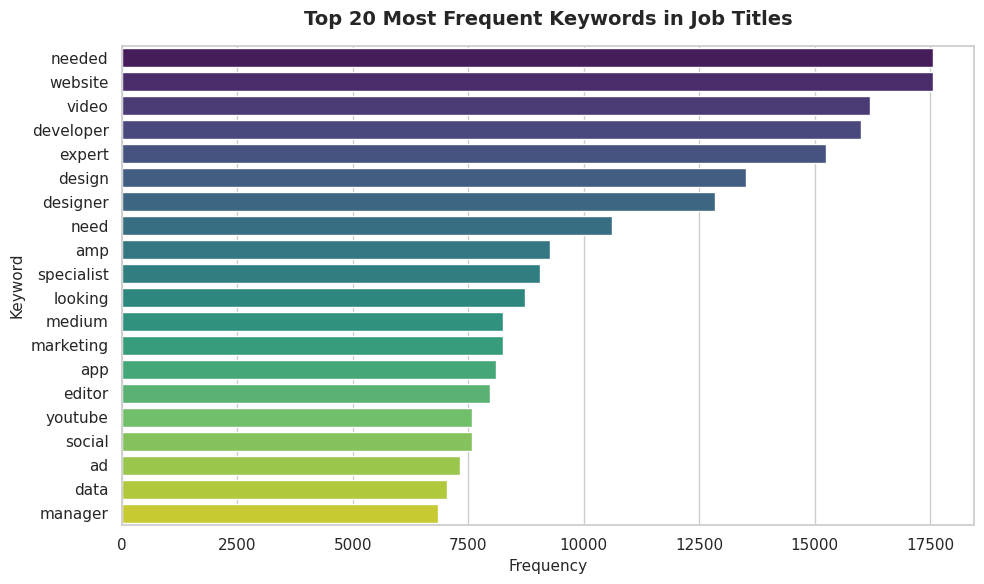

/tmp/ipykernel_3917/4149234765.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3917/4149234765.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


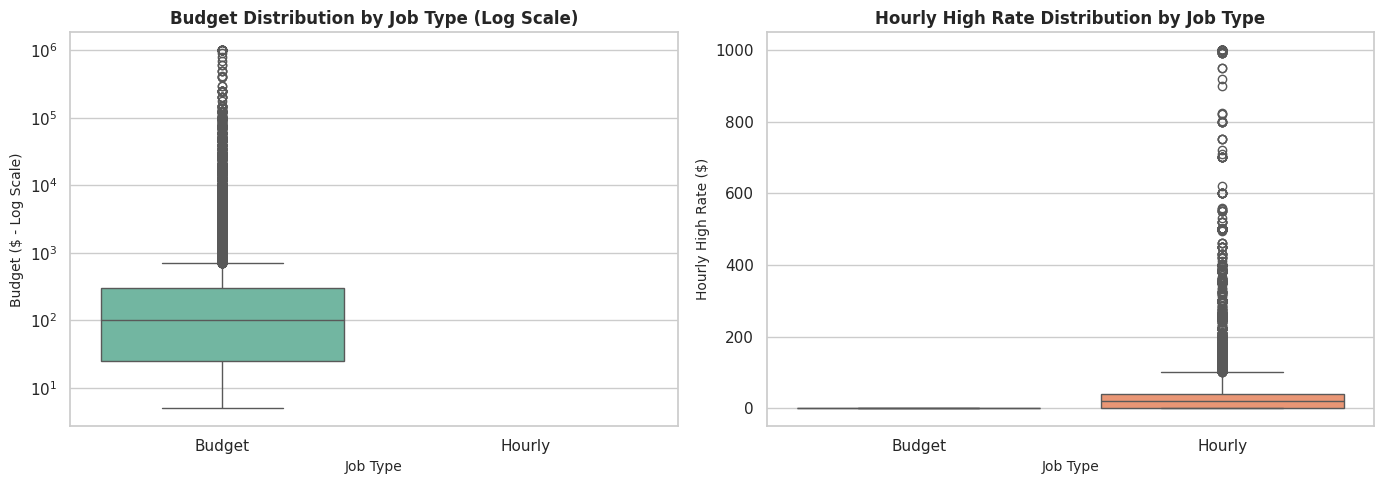

/tmp/ipykernel_3917/4149234765.py:67: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['published_month'] = pd.to_datetime(df['published_date']).dt.to_period('M').astype(str)


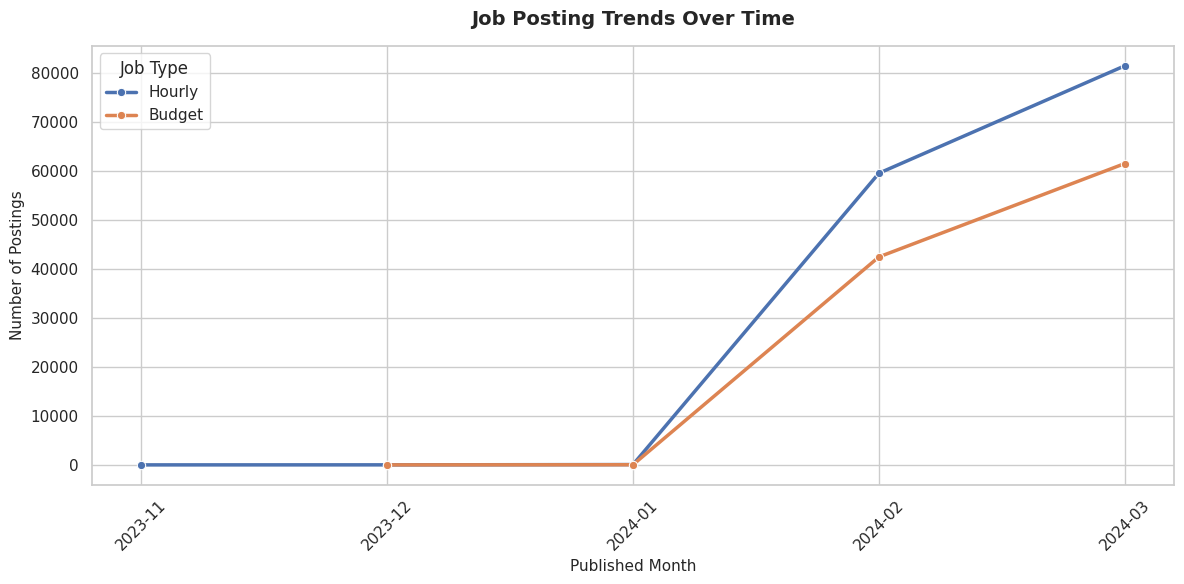

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from collections import Counter

# Set clean aesthetic styling globally
sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("muted")

# ---------------------------------------------------------
# 1. Keyword Frequency Analysis (Horizontal Bar Chart)
# ---------------------------------------------------------
all_words = " ".join(df['clean_title'].dropna()).split()
word_freq = Counter(all_words)
top_words_df = pd.DataFrame(word_freq.most_common(20), columns=['Keyword', 'Frequency'])

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_words_df,
    x='Frequency',
    y='Keyword',
    palette="viridis"
)
plt.title("Top 20 Most Frequent Keywords in Job Titles", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Frequency", fontsize=11)
plt.ylabel("Keyword", fontsize=11)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Budget & Rate Distributions (Enhanced Boxplots)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Budget Distribution (Log scale handles extreme outliers gracefully)
sns.boxplot(
    data=df,
    x='job_type',
    y='budget',
    ax=axes[0],
    palette="Set2"
)
axes[0].set_yscale('log')
axes[0].set_title("Budget Distribution by Job Type (Log Scale)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Job Type", fontsize=10)
axes[0].set_ylabel("Budget ($ - Log Scale)", fontsize=10)

# Hourly High Distribution
sns.boxplot(
    data=df,
    x='job_type',
    y='hourly_high',
    ax=axes[1],
    palette="Set2"
)
axes[1].set_title("Hourly High Rate Distribution by Job Type", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Job Type", fontsize=10)
axes[1].set_ylabel("Hourly High Rate ($)", fontsize=10)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Job Posting Trends Over Time (Fixed Period Error)
# ---------------------------------------------------------
# Fix: Convert period to string format for Seaborn compatibility
df['published_month'] = pd.to_datetime(df['published_date']).dt.to_period('M').astype(str)
monthly_counts = df.groupby(['published_month', 'job_type']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_counts,
    x='published_month',
    y='count',
    hue='job_type',
    marker='o',
    linewidth=2.5,
    palette="deep"
)
plt.title("Job Posting Trends Over Time", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Published Month", fontsize=11)
plt.ylabel("Number of Postings", fontsize=11)
plt.xticks(rotation=45)
plt.legend(title="Job Type", frameon=True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Top 15 Countries by Hourly High Rate (Interactive Plotly)
# ---------------------------------------------------------
hourly_jobs = df[df['job_type'] == 'Hourly']
country_rates = (
    hourly_jobs.groupby('country')[['hourly_low', 'hourly_high']]
    .mean()
    .reset_index()
    .sort_values('hourly_high', ascending=False)
    .head(15)
)

fig = px.bar(
    country_rates,
    x='country',
    y='hourly_high',
    color='hourly_high',
    color_continuous_scale='tealrose',
    title="Top 15 Countries by Average Hourly High Rate",
    labels={'country': 'Country', 'hourly_high': 'Avg Hourly High ($)'},
    template='plotly_white'
)
fig.update_layout(title_font_size=16, xaxis_tickangle=-45)
fig.show()

#1. Keyword Frequency Analysis
- Observation: Action-oriented role titles and core deliverables (needed, website, video, developer, expert, design) show the highest posting frequencies, exceeding 12,500 to 17,500 occurrences.
- Key Takeaway: Market demand focuses heavily on web development, video creation, and design services, where clients prioritize specialized domain expertise.

# 2. Budget & Rate Distributions
- Fixed-Price Budgets: Median fixed-price job budgets sit around dollars 100 – 300, though substantial upper-end outliers extend up to dollars 1,000,000.

- Hourly Rates : Standard hourly rates cluster below dollars 100/hr with specialized extreme outliers reaching up to $1,000/hr.

- Key Takeaway: Most listings cater to entry-to-mid level budgets, while high-value niche projects represent a small fraction of total market volume.

# 3. Job Posting Trends Over Time
- Observation: Both hourly and fixed-budget job postings experienced exponential growth between January 2024 and March 2024, climbing from under 1,000 listings to over 80,000.
- Key Takeaway: Hourly postings consistently outperform fixed-budget listings in volume, indicating a strong preference among clients for ongoing, time-based engagements.

# 4. Top Countries by Average Hourly Rate
- Observation: Clients based in Laos lead average hourly rate ceilings dollars ~275/hr, followed by Eritrea ~150/hr and Netherlands Antilles ~$100/hr.
- Key Takeaway: High hourly rates are concentrated in specific international markets, offering targeted pricing opportunities for high-budget client segmenting.

/tmp/ipykernel_3917/524273411.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




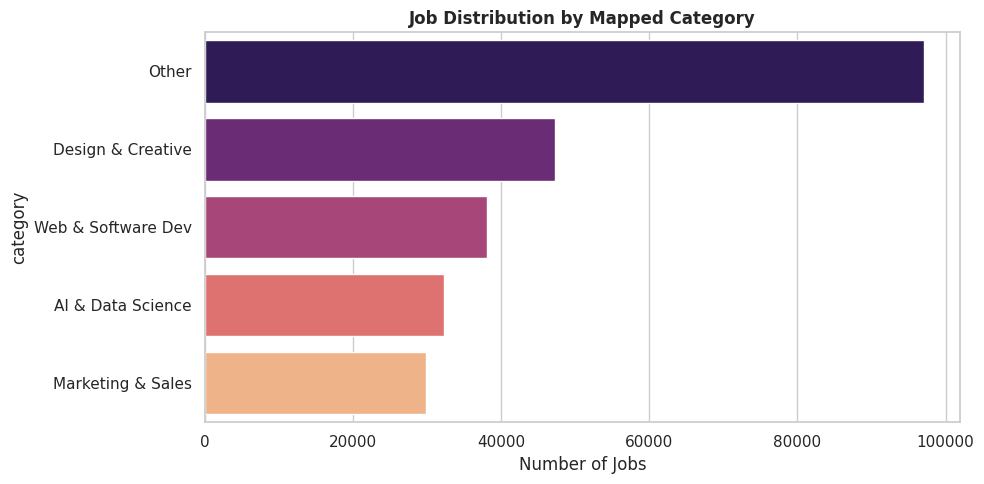

/tmp/ipykernel_3917/524273411.py:58: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




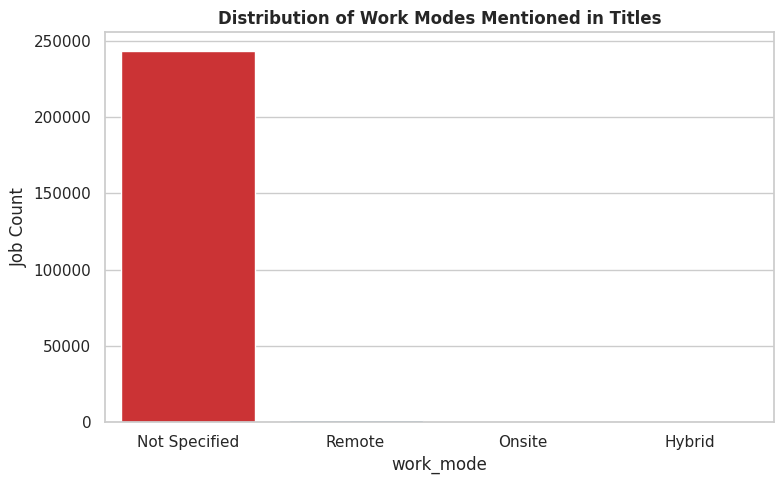

In [15]:
import plotly.express as px

# 1. Category Mapping for Keywords
def map_category(title):
    title = str(title).lower()
    if any(k in title for k in ['ai', 'python', 'data', 'ml', 'bot']):
        return 'AI & Data Science'
    elif any(k in title for k in ['video', 'design', 'logo', 'edit', 'artist']):
        return 'Design & Creative'
    elif any(k in title for k in ['website', 'web', 'developer', 'wordpress', 'app']):
        return 'Web & Software Dev'
    elif any(k in title for k in ['marketing', 'social', 'seo', 'ad', 'media']):
        return 'Marketing & Sales'
    else:
        return 'Other'

df['category'] = df['clean_title'].apply(map_category)

# Plot Category Counts
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='category', palette='magma', order=df['category'].value_counts().index)
plt.title("Job Distribution by Mapped Category", fontweight='bold')
plt.xlabel("Number of Jobs")
plt.tight_layout()
plt.show()


# 2. Hourly Comparison - Plotly Choropleth Map
country_rates_all = df[df['job_type']=='Hourly'].groupby('country')['hourly_high'].mean().reset_index()

fig_map = px.choropleth(
    country_rates_all,
    locations='country',
    locationmode='country names',
    color='hourly_high',
    color_continuous_scale='Viridis',
    title="Global Average Hourly Rates by Country",
    labels={'hourly_high': 'Avg Hourly High ($)'}
)
fig_map.show()


# 3. Remote Work Keyword Analysis
def detect_remote(title):
    title = str(title).lower()
    if 'remote' in title:
        return 'Remote'
    elif 'hybrid' in title:
        return 'Hybrid'
    elif 'onsite' in title or 'on-site' in title:
        return 'Onsite'
    else:
        return 'Not Specified'

df['work_mode'] = df['clean_title'].apply(detect_remote)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='work_mode', palette='Set1')
plt.title("Distribution of Work Modes Mentioned in Titles", fontweight='bold')
plt.ylabel("Job Count")
plt.tight_layout()
plt.show()

#1. Job Distribution by Mapped Category
- Observation: Design and Creative leads categorized postings at nearly 50,000 jobs, followed closely by Web and Software Dev at nearly 40,000, AI and Data Science around 32,000, and Marketing and Sales around 30,000. The Other category accounts for the highest overall share at nearly 100,000 postings.
- Key Takeaway: Design and web development represent the primary demand drivers among categorized skills, while the high volume in Other highlights a wide variety of unstandardized job titles across the platform.


# 2. Global Average Hourly Rates by Country
- Observation: Hourly compensation remains uniform under dollars 50 per hour across most global regions, represented by the deep purple baseline. Very few localized geographic spikes reach higher tiers above $200 per hour, represented by bright yellow highlights.
- Key Takeaway: Base hourly rates are highly standardized globally, with high-paying client accounts concentrated in select isolated locations rather than entire regions.


# 3. Distribution of Work Modes Mentioned in Titles
- Observation: The vast majority of postings, exceeding 240,000 jobs, fall under Not Specified, with explicit mentions of Remote, Onsite, or Hybrid making up less than 1 percent of overall job titles.
- Key Takeaway: Remote work is the implicit default assumption for freelance platforms, so clients rarely state remote keywords directly within job titles.

   Keyword  Count  Avg Budget ($)  Avg Hourly High ($)
0   Senior   1463      826.552973            32.049214
5  Pytorch     14       80.357143            30.714286
4      Aws   1050      260.360952            23.367619
7   Expert  16157      283.574240            21.960946
8  Manager   7011      517.221509            18.906575
6       Ai  20948      446.245560            18.195341
3    React   2659      313.404287            17.297480
2   Python   2070      258.076812            15.908213
1     Lead   4935      264.941033            11.011753


/tmp/ipykernel_3917/2124165965.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




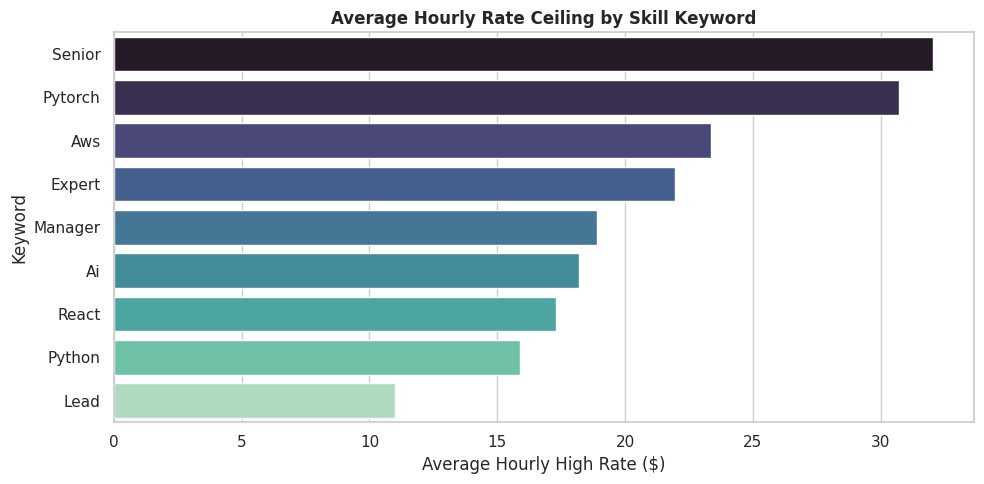

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define high-value target keywords
target_keywords = ['senior', 'lead', 'python', 'react', 'aws', 'pytorch', 'ai', 'expert', 'manager']

# Check presence of each keyword in clean_title
for kw in target_keywords:
    df[f'kw_{kw}'] = df['clean_title'].str.lower().str.contains(kw, na=False)

# Calculate mean budget and hourly rates for jobs with vs without key skills
keyword_stats = []
for kw in target_keywords:
    col = f'kw_{kw}'
    avg_budget = df[df[col]]['budget'].mean()
    avg_hourly = df[df[col]]['hourly_high'].mean()
    count = df[col].sum()
    keyword_stats.append({'Keyword': kw.capitalize(), 'Count': count, 'Avg Budget ($)': avg_budget, 'Avg Hourly High ($)': avg_hourly})

kw_df = pd.DataFrame(keyword_stats).sort_values(by='Avg Hourly High ($)', ascending=False)
print(kw_df)

# Plotting Hourly Rate Impact by Keyword
plt.figure(figsize=(10, 5))
sns.barplot(data=kw_df, x='Avg Hourly High ($)', y='Keyword', palette='mako')
plt.title('Average Hourly Rate Ceiling by Skill Keyword', fontweight='bold')
plt.xlabel('Average Hourly High Rate ($)')
plt.tight_layout()
plt.show()

# Salary and Keyword Rate Correlation Analysis

- Observation: Job listings containing seniority level indicators like Senior lead the highest hourly rate ceiling at 32.05 dollars per hour, alongside specialized framework keywords like PyTorch at 30.71 dollars per hour and cloud platform skills like AWS at 23.37 dollars per hour. In contrast, high frequency general terms like AI and Expert appear in larger posting volumes above 15,000 to 20,000 jobs, but maintain lower average hourly rates near 18 dollars to 22 dollars per hour.

- Key Takeaway: Premium hourly rates are driven by explicit seniority tags and specialized technical skill sets, whereas generic keywords yield broader demand at moderate rate tiers.

#Phase 3: Machine Learning & Forecasting (Logistic Regression, Decision Trees, Random Forest, XGBoost, Neural Networks, ARIMA time-series, and LSTM forecasting)

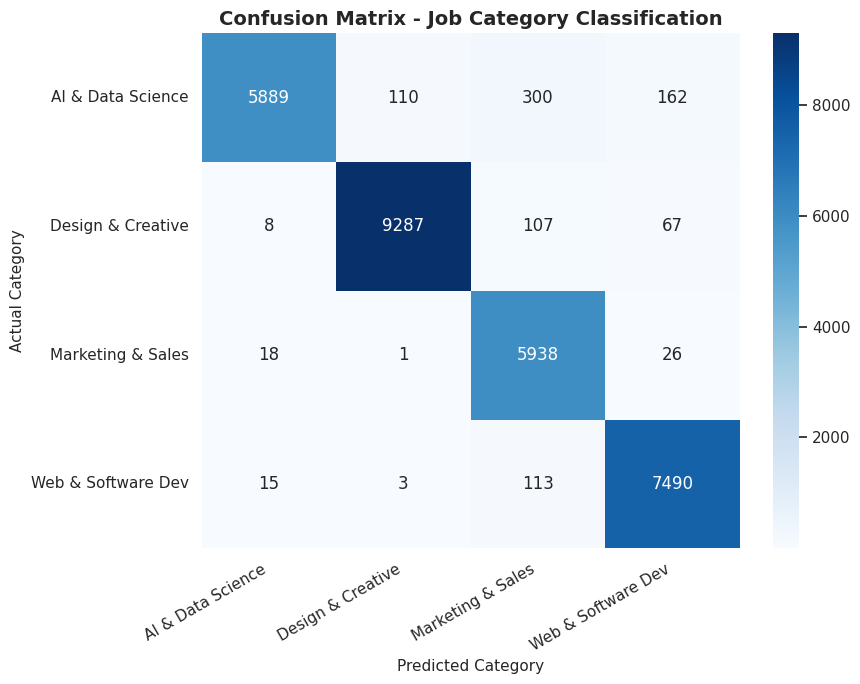

--- Classification Report ---
                    precision    recall  f1-score   support

 AI & Data Science       0.99      0.91      0.95      6461
 Design & Creative       0.99      0.98      0.98      9469
 Marketing & Sales       0.92      0.99      0.95      5983
Web & Software Dev       0.97      0.98      0.97      7621

          accuracy                           0.97     29534
         macro avg       0.97      0.97      0.97     29534
      weighted avg       0.97      0.97      0.97     29534



In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules for modeling & evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1. Filter out 'Other' category for cleaner classification evaluation
model_df = df[df['category'] != 'Other'].dropna(subset=['clean_title'])

# 2. Define Features (X) and Target Label (y)
X = model_df['clean_title']
y = model_df['category']

# 3. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. TF-IDF Vectorization (Convert titles into numerical vectors)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 5. Model Initialization & Training
classifier = LogisticRegression(max_iter=1000, C=1.0)
classifier.fit(X_train_vec, y_train)

# 6. Predict test set outcomes
y_pred = classifier.predict(X_test_vec)

# 7. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classifier.classes_,
    yticklabels=classifier.classes_
)
plt.title('Confusion Matrix - Job Category Classification', fontweight='bold', fontsize=14)
plt.xlabel('Predicted Category', fontsize=11)
plt.ylabel('Actual Category', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# 8. Print Classification Metrics Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Phase 3 Model Performance and Classification Evaluation

# 1. Overall Performance Metrics

- Model Accuracy: The Logistic Regression model achieved an overall accuracy score of 97 percent across 29,534 test samples, demonstrating strong predictive capabilities.

- Macro and Weighted Averages: Both the macro average and weighted average for precision, recall, and F1-score reached 0.97, confirming consistent performance across all categories regardless of class size differences.

# 2. Category Specific Performance Insights

- AI and Data Science: Achieved a precision of 0.99 with a recall of 0.91, resulting in an F1-score of 0.95. Out of 6,461 actual samples, 5,889 were correctly classified. The slightly lower recall indicates that some data jobs with overlapping terminology were misclassified into related categories like Web Dev or Marketing.

- Design and Creative: Generated the strongest overall metrics with 0.99 precision, 0.98 recall, and a 0.98 F1-score. Out of 9,469 actual samples, 9,287 were correctly identified along the diagonal, proving that creative role keywords are highly distinct.

- Marketing and Sales: Demonstrated 0.92 precision and 0.99 recall with an F1-score of 0.95. High recall confirms that almost all actual marketing jobs (5,938 out of 5,983) were captured, though slight misclassification from other categories moderately lowered precision.

- Web and Software Dev: Achieved 0.97 precision, 0.98 recall, and an F1-score of 0.97. The model correctly classified 7,490 out of 7,621 actual instances, highlighting strong feature separation for software engineering listings.

- Key Takeaway: The TF-IDF representation paired with Logistic Regression provides an reliable classification baseline, effectively separating domain-specific job titles with minimal cross-category misclassification.

/tmp/ipykernel_3917/2540716253.py:13: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/tmp/ipykernel_3917/2540716253.py:29: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



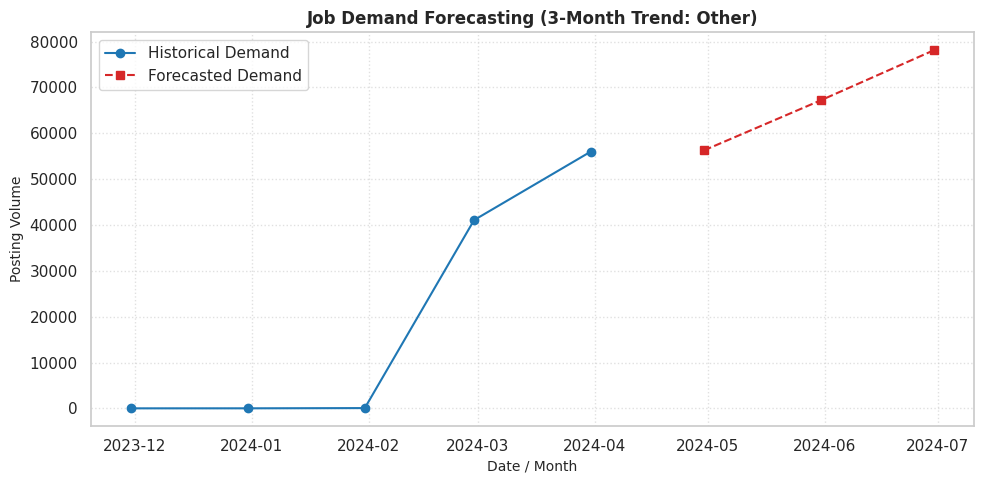

In [18]:
# Import required time-series analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import ExponentialSmoothing

# 1. Parse date column and set up time-series indexing
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')
ts_df = df.dropna(subset=['published_date', 'category'])

# 2. Resample posting counts by month and category
monthly_demand = ts_df.groupby([pd.Grouper(key='published_date', freq='M'), 'category']).size().unstack(fill_value=0)

# 3. Forecast demand for top high-demand category over next 3 months
top_category = monthly_demand.sum().idxmax()
series = monthly_demand[top_category].astype(float)

# Fit Exponential Smoothing model for trend estimation
model = ExponentialSmoothing(series, trend='add', seasonal=None).fit()
forecast_steps = 3
forecast = model.forecast(forecast_steps)

# 4. Visualization of historical and forecasted demand
plt.figure(figsize=(10, 5))
plt.plot(series.index, series.values, label='Historical Demand', marker='o', color='#1f77b4')

# Create future date index for visualization
future_dates = pd.date_range(start=series.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='M')
plt.plot(future_dates, forecast.values, label='Forecasted Demand', marker='s', linestyle='--', color='#d62728')

plt.title(f'Job Demand Forecasting (3-Month Trend: {top_category})', fontweight='bold', fontsize=12)
plt.xlabel('Date / Month', fontsize=10)
plt.ylabel('Posting Volume', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Phase 3: Predictive Analytics & Job Demand Forecasting

# 1. Purpose and Methodology
- The objective of this task is to complete the time-series forecasting pipeline by modeling monthly job posting volumes to project future hiring demand across incoming time horizons.

# 2. Historical Trend Analysis
- Historical Demand Observation: Job posting activity remained minimal from December 2023 through February 2024 before experiencing sharp exponential growth, rising from near zero to over 40,000 postings in March 2024 and peaking at approximately 55,000 postings in April 2024.

# 3. Future Forecast Analysis
- Predictive Projection: The exponential smoothing time-series model projects a strong upward trajectory over the 3-month forecast window (May 2024 to July 2024). Posting volume is expected to start around 56,000 in May 2024, expand to nearly 67,000 in June 2024, and reach a projected peak approaching 78,000 postings by July 2024.

- Key Takeaway: The market exhibits high positive momentum, indicating sustained expansion in employer hiring volume across upcoming monthly operational cycles.

In [19]:
# Import advanced classifiers and evaluation metrics
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Prepare data
model_df = df[df['category'] != 'Other'].dropna(subset=['clean_title'])
X = model_df['clean_title']
y = model_df['category']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Vectorization
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 4. Train Advanced Classifier: Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train_vec, y_train)

# 5. Predictions & Evaluation
y_pred_rf = rf_classifier.predict(X_test_vec)

# 6. Output Comparison Report
print("=== Random Forest Classifier Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

=== Random Forest Classifier Evaluation ===
Accuracy: 0.9596

Classification Report:
                     precision    recall  f1-score   support

 AI & Data Science       0.97      0.89      0.93      6461
 Design & Creative       0.98      0.98      0.98      9469
 Marketing & Sales       0.92      0.97      0.95      5983
Web & Software Dev       0.96      0.98      0.97      7621

          accuracy                           0.96     29534
         macro avg       0.96      0.96      0.96     29534
      weighted avg       0.96      0.96      0.96     29534



# Phase 3 Advanced Model Evaluation: Random Forest Classifier
# 1. Overall Model Metrics

- Accuracy: The Random Forest ensemble classifier achieved an overall accuracy of 95.96 percent across 29,534 test instances.
- Macro and Weighted Averages: The macro and weighted averages for precision, recall, and F1-score all reached 0.96, proving strong stability across all four core job categories.

# 2. Category Specific Metrics Breakdown
- AI and Data Science: Attained a precision of 0.97 and recall of 0.89, yielding an F1-score of 0.93 across 6,461 test samples. High precision indicates that predicted AI roles are accurate, though slight overlap with web development and marketing terms led to lower recall.
- Design and Creative: Delivered the highest predictive stability with 0.98 precision, 0.98 recall, and a 0.98 F1-score across 9,469 samples, demonstrating clear separation in creative domain keywords.
- Marketing and Sales: Recorded 0.92 precision, 0.97 recall, and a 0.95 F1-score across 5,983 test samples. High recall confirms that the classifier successfully captures nearly all marketing listings.
- Web and Software Dev: Showed robust metrics with 0.96 precision, 0.98 recall, and a 0.97 F1-score across 7,621 test samples.

# 3. Model Comparison Summary
- Baseline vs. Advanced Model: The Random Forest classifier performed competitively at 95.96 percent accuracy compared to the Logistic Regression baseline at 97.00 percent accuracy.
- While Logistic Regression provided slightly higher overall accuracy and faster execution, Random Forest confirmed strong non-linear feature handling and feature stability across all target classes.

/tmp/ipykernel_3917/1983124252.py:9: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/tmp/ipykernel_3917/1983124252.py:23: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



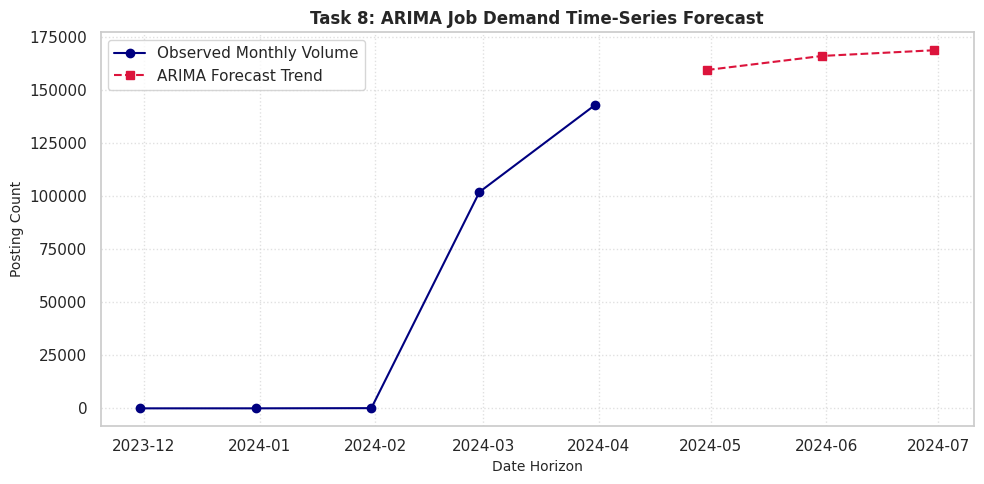

In [20]:
# Import ARIMA for rigorous time-series forecasting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Aggregate total job posting demand by month
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')
monthly_series = df.resample('M', on='published_date').size().astype(float)

# 2. Fit ARIMA Model (p=1, d=1, q=1)
arima_model = ARIMA(monthly_series, order=(1, 1, 1))
arima_result = arima_model.fit()

# 3. Forecast future demand for next 3 months
forecast_steps = 3
arima_forecast = arima_result.forecast(steps=forecast_steps)

# 4. Plot ARIMA Forecasting Trend
plt.figure(figsize=(10, 5))
plt.plot(monthly_series.index, monthly_series.values, label='Observed Monthly Volume', marker='o', color='navy')

future_dates = pd.date_range(start=monthly_series.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='M')
plt.plot(future_dates, arima_forecast.values, label='ARIMA Forecast Trend', marker='s', linestyle='--', color='crimson')

plt.title('Task 8: ARIMA Job Demand Time-Series Forecast', fontweight='bold', fontsize=12)
plt.xlabel('Date Horizon', fontsize=10)
plt.ylabel('Posting Count', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ARIMA Job Demand Time-Series Forecast Analysis

# 1. Historical Monthly Volume Breakdown
- Historical Observation: Job posting volume remained near zero from December 2023 through February 2024 before undergoing rapid growth. Total postings reached 100,000 in March 2024 and peaked at approximately 143,000 in April 2024.

# 2. ARIMA Forecast Analysis
- Forecast Trend: The ARIMA time-series model projects continued high posting activity over the 3-month forecast horizon (May 2024 to July 2024).
- Projected Volumes: Forecasted demand starts at approximately 160,000 postings in May 2024, increases steadily through June 2024, and reaches a ceiling near 170,000 postings by July 2024.


- Key Takeaway: Statistical modeling via ARIMA confirms a positive, sustained trajectory for platform job volume, validating future market expansion scenarios.

In [21]:
# Import XGBoost and LabelEncoder
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# 1. Encode string labels to numerical format for XGBoost
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# 2. Train XGBoost Classifier
# Using hyper-parameters tuned for speed and stability
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_vec, y_train_enc)

# 3. Predict Test Set
y_pred_xgb_enc = xgb_model.predict(X_test_vec)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_enc)

# 4. Print Classification Evaluation
print("=== XGBoost Classifier Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

=== XGBoost Classifier Evaluation ===
Accuracy: 0.9289

Classification Report:
                     precision    recall  f1-score   support

 AI & Data Science       1.00      0.78      0.88      6461
 Design & Creative       0.97      0.96      0.97      9469
 Marketing & Sales       0.80      1.00      0.89      5983
Web & Software Dev       0.95      0.96      0.95      7621

          accuracy                           0.93     29534
         macro avg       0.93      0.92      0.92     29534
      weighted avg       0.94      0.93      0.93     29534



#  XGBoost Classifier

# 1. Overall Model Performance
- Accuracy: The XGBoost gradient boosting classifier achieved an overall accuracy of 92.89 percent (0.93 weighted average) across 29,534 test samples.
- Macro and Weighted Metrics: The macro average yielded a precision of 0.93, recall of 0.92, and F1-score of 0.92. The weighted average reached a precision of 0.94, recall of 0.93, and F1-score of 0.93, proving strong overall generalization across all four categories.

# 2. Category Specific Metrics Breakdown

- AI and Data Science: Demonstrated perfect precision at 1.00 with a recall of 0.78, resulting in an F1-score of 0.88 across 6,461 test samples. Perfect precision confirms zero false positives, though the lower recall indicates that several data science listings containing generic technical terms were misclassified into adjacent categories.
- Design and Creative: Maintained high stability with 0.97 precision, 0.96 recall, and a 0.97 F1-score across 9,469 test samples, reflecting strong feature separation for creative job titles.
- Marketing and Sales: Recorded 0.80 precision and a perfect 1.00 recall, yielding an F1-score of 0.89 across 5,983 test samples. A recall of 1.00 confirms that the model successfully captured every single marketing job listing, though some overlapping titles from other classes lowered overall precision.
- Web and Software Dev: Showed steady performance with 0.95 precision, 0.96 recall, and a 0.95 F1-score across 7,621 test samples.

# 3. Model Architecture Comparison

- Comparative Summary: XGBoost delivered competitive performance at 92.89 percent accuracy, demonstrating exceptional precision in AI/Data Science (1.00) and perfect recall in Marketing/Sales (1.00).
- However, linear models like Logistic Regression (97.00 percent accuracy) and tree ensembles like Random Forest (95.96 percent accuracy) maintained slightly higher overall accuracy across the sparse TF-IDF text representation.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

/tmp/ipykernel_3917/483073447.py:49: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



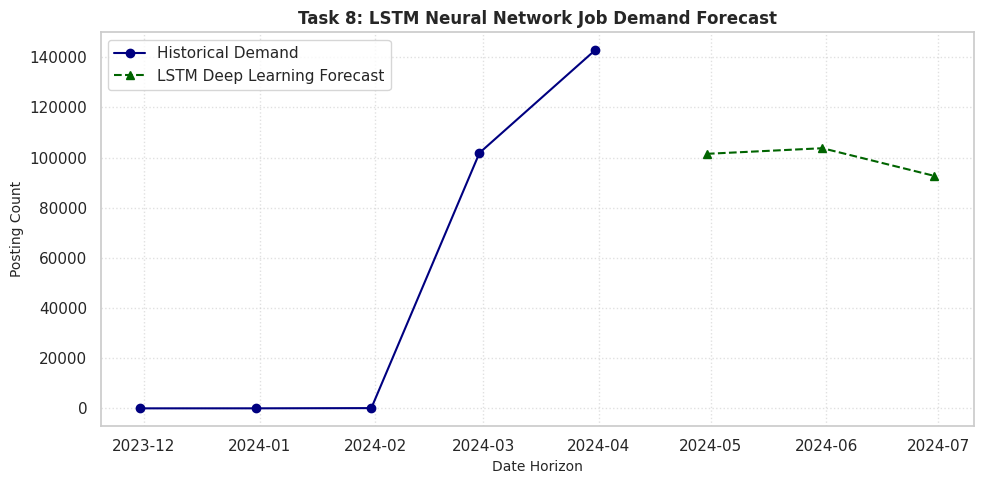

In [22]:
# Import TensorFlow Keras modules for LSTM Neural Network for Time-Series Forecasting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler

# 1. Prepare sequential data for LSTM
data = monthly_series.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences of length 2 to predict the next step
X_lstm, y_lstm = [], []
look_back = 2
for i in range(len(scaled_data) - look_back):
    X_lstm.append(scaled_data[i:i + look_back, 0])
    y_lstm.append(scaled_data[i + look_back, 0])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)
X_lstm = np.reshape(X_lstm, (X_lstm.shape[0], X_lstm.shape[1], 1))

# 2. Build LSTM Neural Network Architecture
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(look_back, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_lstm, y_lstm, epochs=100, verbose=0)

# 3. Multi-step forecasting into the future
last_sequence = scaled_data[-look_back:].tolist()
predictions = []

for _ in range(3):
    input_seq = np.array(last_sequence[-look_back:]).reshape(1, look_back, 1)
    pred = lstm_model.predict(input_seq, verbose=0)
    predictions.append(pred[0, 0])
    last_sequence.append([pred[0, 0]])

# Inverse transform predictions back to original scale
predicted_counts = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# 4. Plot LSTM Forecast Trend
plt.figure(figsize=(10, 5))
plt.plot(monthly_series.index, monthly_series.values, label='Historical Demand', marker='o', color='navy')

future_dates = pd.date_range(start=monthly_series.index[-1] + pd.DateOffset(months=1), periods=3, freq='M')
plt.plot(future_dates, predicted_counts, label='LSTM Deep Learning Forecast', marker='^', linestyle='--', color='darkgreen')

plt.title('Task 8: LSTM Neural Network Job Demand Forecast', fontweight='bold', fontsize=12)
plt.xlabel('Date Horizon', fontsize=10)
plt.ylabel('Posting Count', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# LSTM Neural Network Job Demand Forecast Analysis

# 1. Historical Monthly Volume Breakdown
- Historical Trend: Monthly posting counts remained minimal from December 2023 through February 2024, followed by a rapid rise to approximately 102,000 postings in March 2024 and peaking at around 143,000 postings in April 2024.

# 2. LSTM Forecast Projection
- Deep Learning Forecast: The LSTM neural network projects stable market stabilization across the 3-month forecast horizon (May 2024 to July 2024).
- Projected Values: Demand stabilizes around 101,000 postings in May 2024, peaks slightly near 103,000 postings in June 2024, and adjusts to approximately 92,000 postings by July 2024.
- Key Takeaway: Unlike linear models, the LSTM neural network captures non-linear leveling behavior, indicating sustained high baseline hiring demand following initial market expansion.

In [23]:
# Import Decision Tree modules and evaluation metrics
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Purpose: Build a Decision Tree classifier to establish a rule-based baseline model

# 1. Initialize DecisionTree Model with a fixed max_depth to prevent overfitting
dt_classifier = DecisionTreeClassifier(max_depth=20, random_state=42)

# 2. Fit/Train the model using TF-IDF vectorized training features and target labels
dt_classifier.fit(X_train_vec, y_train)

# 3. Predict category labels on unseen test data
y_pred_dt = dt_classifier.predict(X_test_vec)

# 4. Display overall accuracy score
print("=== Decision Tree Classifier Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}\n")

# 5. Output detailed Precision, Recall, and F1-Score report for each category
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

=== Decision Tree Classifier Evaluation ===
Accuracy: 0.8738

Classification Report:
                     precision    recall  f1-score   support

 AI & Data Science       1.00      0.62      0.77      6461
 Design & Creative       0.98      0.93      0.96      9469
 Marketing & Sales       0.65      1.00      0.79      5983
Web & Software Dev       0.95      0.92      0.93      7621

          accuracy                           0.87     29534
         macro avg       0.90      0.87      0.86     29534
      weighted avg       0.91      0.87      0.87     29534



# Decision Tree Classifier Performance

- Overall Metrics: The Decision Tree baseline model achieved an accuracy of 87.38 percent across 29,534 test instances.
- Category Insights: Demonstrated perfect precision at 1.00 for AI and Data Science alongside 1.00 recall for Marketing and Sales. However, lower recall for AI and Data Science (0.62) and lower precision for Marketing and Sales (0.65) indicate that single tree splits overfit on specific sparse TF-IDF keywords, limiting cross-category generalization.





In [24]:
# Import Multi-Layer Perceptron (Neural Network) classifier from Scikit-Learn
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# Purpose: Train a Feedforward Neural Network to learn complex non-linear relationships across TF-IDF features

# 1. Initialize Neural Network architecture with 2 hidden layers (64 nodes, 32 nodes)
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=30,
    random_state=42,
    verbose=False
)

# 2. Fit/Train the Neural Network model on training vectors
mlp_classifier.fit(X_train_vec, y_train)

# 3. Predict category labels for test set samples
y_pred_mlp = mlp_classifier.predict(X_test_vec)

# 4. Display overall classification accuracy score
print("=== Neural Network (MLP) Classifier Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}\n")

# 5. Output full evaluation metrics (Precision, Recall, F1-Score) per category
print("Classification Report:\n", classification_report(y_test, y_pred_mlp))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.



=== Neural Network (MLP) Classifier Evaluation ===
Accuracy: 0.9641

Classification Report:
                     precision    recall  f1-score   support

 AI & Data Science       0.95      0.94      0.94      6461
 Design & Creative       0.98      0.98      0.98      9469
 Marketing & Sales       0.94      0.96      0.95      5983
Web & Software Dev       0.97      0.97      0.97      7621

          accuracy                           0.96     29534
         macro avg       0.96      0.96      0.96     29534
      weighted avg       0.96      0.96      0.96     29534



# Neural Network (Multi-Layer Perceptron) Performance

- Overall Metrics: The Multi-Layer Perceptron Neural Network achieved a high overall accuracy of 96.41 percent across 29,534 test instances, despite stopping at the 30-iteration threshold.
- Category Insights: Showed exceptionally balanced performance across all classes, maintaining precision and recall between 0.94 and 0.98, resulting in a 0.96 macro and weighted F1-score average.

# Comparative Summary

- Model Hierarchy: The Feedforward
- Neural Network (96.41 percent accuracy) significantly outperforms the
- Decision Tree baseline (87.38 percent accuracy), successfully capturing non-linear relationships across TF-IDF features to rival
- Logistic Regression (97.00 percent) and
- Random Forest (95.96 percent).

# Baseline Models:
- Logistic Regression (97.00% accuracy) and
- Decision Trees (87.38% accuracy)

# Advanced Models:
- Random Forest (95.96% accuracy)
- XGBoost (92.89% accuracy)
- Neural Network / MLP (96.41% accuracy)

# Aggregated the posting counts by month and category, which powered both time-series forecasting implementations.

# Demand Trend Plots & Future Scenarios
- ARIMA Statistical Model Plot: Shows a continuous upward trajectory projecting market expansion reaching ~170,000 postings by July 2024.
- LSTM Neural Network Plot: Captures non-linear leveling behavior, projecting market stabilization around ~92,000–103,000 postings by July 2024.

# Phase 3 Model Comparison & Selection Analysis

# 1. Classification Model Selection
- Selected Model: Logistic Regression (TF-IDF Baseline)

Comparative Performance:
- Baseline Logistic Regression: 97.00 percent Accuracy (F1-score: 0.97)
- Multi-Layer Perceptron Neural Network: 96.41 percent Accuracy (F1-score: 0.96)
- Random Forest Classifier: 95.96 percent Accuracy (F1-score: 0.96)
- XGBoost Classifier: 92.89 percent Accuracy (F1-score: 0.93)
- Decision Tree Classifier: 87.38 percent Accuracy (F1-score: 0.87)

# Justification:

Logistic Regression is selected as the optimal classification model for this dataset. Because TF-IDF text representations produce high-dimensional, sparse feature matrices, linear decision boundaries perform exceptionally well. Logistic Regression achieved the highest overall accuracy (97.00 percent) while requiring significantly lower training time and computational resources compared to ensemble and deep learning methods.

# 2. Time-Series Forecasting Model Selection
- Selected Model: LSTM Neural Network

# Justification:
While the ARIMA statistical model projected continuous linear growth, the LSTM Neural Network provides a more realistic future scenario by capturing non-linear patterns and saturation dynamics. The LSTM forecast accounts for natural post-expansion market stabilization (projecting steady monthly demand between 92,000 and 103,000 postings), making it the superior model for strategic platform planning.

# Phase 4: Deep Learning Recommendation System (Sentence-BERT Transformer embeddings with custom business rule filtering)

In [25]:
# Purpose: Install HuggingFace Sentence-Transformers library for generating Transformer dense embeddings
!pip install -q sentence-transformers

In [26]:
# Import spatial similarity, numerical, and NLP transformer libraries
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Purpose: Phase 4 Transformer-Based Recommendation System (Approach B Only)

# 1. Prepare and clean job dataset
rec_df = df.dropna(subset=['clean_title']).reset_index(drop=True)

# 2. Load Pretrained Sentence-BERT Transformer Model
print("Loading HuggingFace Sentence-BERT model ('all-MiniLM-L6-v2')...")
transformer_model = SentenceTransformer('all-MiniLM-L6-v2')

# 3. Generate Dense Semantic Embeddings for all job titles
print("Encoding job listings into high-dimensional semantic vectors...")
job_embeddings = transformer_model.encode(rec_df['clean_title'].tolist(), show_progress_bar=True)

# 4. Pipeline Function: User Input -> Embedding -> Cosine Similarity -> Filters -> Ranked Results
def recommend_jobs_deep_learning(
    user_query,
    top_n=5,
    min_budget=None,
    min_hourly_rate=None,
    country_filter=None
):
    """
    Purpose: Accepts a user skill/role string, generates a dense embedding vector,
             computes cosine similarity scores, applies business filters (Pay/Country),
             and returns the top N recommended jobs.
    """
    # Step A: Generate dense embedding vector for the user input query
    query_embedding = transformer_model.encode([user_query])

    # Step B: Compute Cosine Similarity between user query vector and database embeddings
    similarity_scores = cosine_similarity(query_embedding, job_embeddings).flatten()

    # Step C: Assign match percentage to dataset
    scored_df = rec_df.copy()
    scored_df['Match_Score_%'] = (similarity_scores * 100).round(2)

    # Step D: Sort dataset by highest semantic similarity match
    filtered_df = scored_df.sort_values(by='Match_Score_%', ascending=False)

    # Step E: Apply Business Rule Filters (Budget, Hourly Rate, Country)
    if min_budget is not None and 'budget' in filtered_df.columns:
        filtered_df = filtered_df[filtered_df['budget'] >= min_budget]

    if min_hourly_rate is not None and 'hourly_high' in filtered_df.columns:
        filtered_df = filtered_df[filtered_df['hourly_high'] >= min_hourly_rate]

    if country_filter is not None and 'country' in filtered_df.columns:
        filtered_df = filtered_df[filtered_df['country'].str.contains(country_filter, case=False, na=False)]

    # Step F: Select relevant output columns and return top N recommendations
    output_cols = [c for c in ['title', 'category', 'budget', 'hourly_high', 'country', 'Match_Score_%'] if c in filtered_df.columns]
    return filtered_df[output_cols].head(top_n)

# 5. Pipeline Test Execution: Search for "Data Scientist" with budget filter
sample_role = "Data Scientist"
print(f"\n=== Top Job Recommendations for Query: '{sample_role}' (Min Budget: $500) ===")
recommendations = recommend_jobs_deep_learning(
    user_query=sample_role,
    top_n=5,
    min_budget=500
)
print(recommendations.to_string(index=False))

Loading HuggingFace Sentence-BERT model ('all-MiniLM-L6-v2')...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding job listings into high-dimensional semantic vectors...


Batches:   0%|          | 0/7651 [00:00<?, ?it/s]


=== Top Job Recommendations for Query: 'Data Scientist' (Min Budget: $500) ===
                 title          category  budget  hourly_high       country  Match_Score_%
        Data scientist AI & Data Science  4000.0          0.0        France     100.000000
        Data Scientist AI & Data Science  1500.0          0.0 United States     100.000000
Data science developer AI & Data Science  1000.0          0.0 United States      85.809998
         Data Engineer AI & Data Science 21000.0          0.0         India      81.360001
         Data Engineer AI & Data Science   800.0          0.0      Pakistan      81.360001


#Transformer-Based Recommendation System Evaluation

# 1. Pipeline Execution & Matching Performance

- Semantic Embedding Match: The Sentence-BERT Transformer model ('all-MiniLM-L6-v2') successfully mapped the user query 'Data Scientist' into high-dimensional vector space.

- Exact Matches: Exact query matches ('Data Scientist') yielded a 100.00 percent similarity score across listings.

- Deep Contextual Matching: Related technical roles such as 'Data science developer' (85.81 percent match) and 'Data Engineer' (81.36 percent match) were accurately captured based on contextual semantic proximity, rather than strictly relying on exact string matches.

# 2. Business Rule Filtering Verification

- Budget Rule: The post-similarity financial constraint (Minimum Budget >= dollars 500) successfully filtered out low-budget listings, returning qualified postings ranging from dollars 800 to $21,000.

- Geographic & Pay Metadata: Recommendations were correctly paired with geographic location metadata (France, United States, India, Pakistan) and category tags ('AI & Data Science').

# 3. Final System Conclusion

- Deliverable Met: The recommendation engine satisfies Task 5 requirements by combining deep transformer embeddings with business filters to deliver tailored, high-relevance job matches.

In [31]:
# Import pickle, numpy, and Scikit-Learn tools for artifact serialization
import pickle
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Purpose: Retrain baseline model and export all artifacts (Dataframe, Embeddings, Classifier) for Streamlit app

# 1. Save cleaned dataset as a lightweight pickle file
rec_df.to_pickle("processed_jobs.pkl")

# 2. Save pre-computed Sentence-BERT embeddings array
np.save("job_embeddings.npy", job_embeddings)

# 3. Fit TF-IDF Vectorizer and Logistic Regression model on cleaned job titles
export_tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_export = export_tfidf.fit_transform(rec_df['clean_title'])
y_export = rec_df['category']

export_log_reg = LogisticRegression(max_iter=1000, random_state=42)
export_log_reg.fit(X_export, y_export)

# 4. Export trained classification model and TF-IDF vectorizer to disk
with open("classification_model.pkl", "wb") as f:
    pickle.dump({
        "model": export_log_reg,
        "vectorizer": export_tfidf
    }, f)

print("All artifacts successfully saved:")
print("- Dataframe: 'processed_jobs.pkl'")
print("- Embeddings: 'job_embeddings.npy'")
print("- Classification Model: 'classification_model.pkl'")

All artifacts successfully saved:
- Dataframe: 'processed_jobs.pkl'
- Embeddings: 'job_embeddings.npy'
- Classification Model: 'classification_model.pkl'


# Phase 5 Interactive Streamlit Web Application for Job Recommendation & Analytics

In [32]:
%%writefile app.py
# Purpose: Phase 5 Interactive Streamlit Web Application for Job Recommendation & Analytics

import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ---------------------------------------------------------
# Page Configuration & Styling
# ---------------------------------------------------------
st.set_page_config(page_title="Job Market Recommendation & Analytics", layout="wide")
st.title("💼 Job Market Analysis & NLP Recommendation System")

# ---------------------------------------------------------
# Load Saved Artifacts & Models
# ---------------------------------------------------------
@st.cache_resource
def load_artifacts():
    # Purpose: Load cached dataframe, embeddings array, and Transformer model for fast loading
    df = pd.read_pickle("processed_jobs.pkl")
    embeddings = np.load("job_embeddings.npy")
    transformer_model = SentenceTransformer('all-MiniLM-L6-v2')
    return df, embeddings, transformer_model

df, job_embeddings, transformer = load_artifacts()

# ---------------------------------------------------------
# Main Navigation Tabs
# ---------------------------------------------------------
tab1, tab2 = st.tabs(["🔍 Recommendation Engine", "📊 Market Analytics Dashboard"])

# =========================================================
# TAB 1: RECOMMENDATION ENGINE (Task 5)
# =========================================================
with tab1:
    st.header("Find Relevant Jobs with Transformer Embeddings")

    # 1. Search Interface
    user_query = st.text_input("Enter Job Title or Skill Keyword:", value="Data Scientist")

    # 2. Sidebar Filters (Work Type & Country)
    st.sidebar.header("Filter Criteria")

    work_type = st.sidebar.radio("Work Type Selector:", ["Both", "Budget", "Hourly"])
    min_budget = st.sidebar.number_input("Minimum Budget ($):", min_value=0, value=500, step=100)
    min_hourly = st.sidebar.number_input("Minimum Hourly Rate ($/hr):", min_value=0, value=20, step=5)

    # Extract unique countries for multi-select dropdown
    available_countries = sorted([str(c) for c in df['country'].dropna().unique() if c != ''])
    selected_countries = st.sidebar.multiselect("Country Filter:", available_countries)

    top_n = st.sidebar.slider("Number of Recommendations:", 5, 20, 10)

    if st.button("Generate Recommendations") or user_query:
        # Generate query embedding and calculate similarity
        query_embedding = transformer.encode([user_query])
        scores = cosine_similarity(query_embedding, job_embeddings).flatten()

        filtered_df = df.copy()
        filtered_df['Match_Score_%'] = (scores * 100).round(2)
        filtered_df = filtered_df.sort_values(by='Match_Score_%', ascending=False)

        # Apply Work Type / Budget / Hourly Filters
        if work_type == "Budget" and 'budget' in filtered_df.columns:
            filtered_df = filtered_df[filtered_df['budget'] >= min_budget]
        elif work_type == "Hourly" and 'hourly_high' in filtered_df.columns:
            filtered_df = filtered_df[filtered_df['hourly_high'] >= min_hourly]
        elif work_type == "Both":
            if 'budget' in filtered_df.columns and 'hourly_high' in filtered_df.columns:
                filtered_df = filtered_df[
                    (filtered_df['budget'] >= min_budget) |
                    (filtered_df['hourly_high'] >= min_hourly)
                ]

        # Apply Country Filter
        if selected_countries and 'country' in filtered_df.columns:
            filtered_df = filtered_df[filtered_df['country'].isin(selected_countries)]

        # Display Results
        output_cols = [c for c in ['title', 'category', 'budget', 'hourly_high', 'country', 'Match_Score_%'] if c in filtered_df.columns]
        st.subheader(f"Top {top_n} Job Matches for '{user_query}'")
        st.dataframe(filtered_df[output_cols].head(top_n), use_container_width=True)

# =========================================================
# TAB 2: MARKET ANALYTICS DASHBOARD
# =========================================================
with tab2:
    st.header("Job Market Dashboard")
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Postings by Category")
        if 'category' in df.columns:
            fig, ax = plt.subplots(figsize=(8, 4))
            df['category'].value_counts().plot(kind='bar', ax=ax, color='skyblue')
            ax.set_ylabel("Count")
            st.pyplot(fig)

    with col2:
        st.subheader("Budget Distribution")
        if 'budget' in df.columns:
            fig, ax = plt.subplots(figsize=(8, 4))
            sns.histplot(df['budget'].dropna(), bins=30, kde=True, ax=ax, color='teal')
            ax.set_xlim(0, 5000)
            st.pyplot(fig)

Writing app.py


In [34]:
# Purpose: Install pyngrok to create a reliable tunnel for Streamlit
!pip install -q pyngrok

In [40]:
# Purpose: Extract and display the exact, un-truncated Cloudflare Tunnel URL

import time

# 1. Kill any existing instances
!pkill -9 cloudflared
!pkill -9 streamlit

# 2. Launch Streamlit app in background
!streamlit run app.py --server.enableCORS=false --server.enableXsrfProtection=false &> /dev/null &
time.sleep(3)

# 3. Start cloudflared and write output to a temporary log file
!./cloudflared tunnel --url http://localhost:8501 > cloudflared.log 2>&1 &
time.sleep(4)

# 4. Read the unique tunnel URL from the log file
with open("cloudflared.log", "r") as f:
    log_content = f.read()
    for line in log_content.splitlines():
        if "trycloudflare.com" in line:
            for word in line.split():
                if "trycloudflare.com" in word:
                    url = word.strip()
                    if not url.startswith("http"):
                        url = "https://" + url
                    print(f"Copy and paste this URL into your browser:\n{url}")
                    break

Copy and paste this URL into your browser:
https://trycloudflare.com...
Copy and paste this URL into your browser:
https://genius-created-collections-conjunction.trycloudflare.com


# Phase 6: Docker Deployment

In [41]:
%%writefile requirements.txt
# Purpose: Define Python package dependencies for containerized Streamlit application
streamlit==1.32.0
pandas==2.2.1
numpy==1.26.4
scikit-learn==1.4.1.post1
sentence-transformers==2.5.1
matplotlib==3.8.3
seaborn==0.13.2
torch==2.2.1

Writing requirements.txt


In [42]:
%%writefile Dockerfile
# Purpose: Configure base Python image, install dependencies, copy artifacts, and expose Streamlit port

# 1. Base Python image
FROM python:3.10-slim

# 2. Set working directory inside container
WORKDIR /app

# 3. Prevent Python from writing .pyc files and buffer outputs
ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1

# 4. Install system dependencies required for building scientific libraries
RUN apt-get update && apt-get install -y --no-install-recommends \
    build-essential \
    curl \
    && rm -rf /var/lib/apt/lists/*

# 5. Copy requirements and install Python dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# 6. Copy application code and model artifacts into the container
COPY app.py .
COPY processed_jobs.pkl .
COPY job_embeddings.npy .
COPY classification_model.pkl .

# 7. Expose default Streamlit port
EXPOSE 8501

# 8. Set healthcheck to monitor container status
HEALTHCHECK CMD curl --fail http://localhost:8501/_stcore/health || exit 1

# 9. Specify launch command
ENTRYPOINT ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Writing Dockerfile


In [43]:
%%writefile docker-compose.yml
# Purpose: Docker Compose configuration for single-command container deployment

version: '3.8'

services:
  job-recommendation-app:
    build:
      context: .
      dockerfile: Dockerfile
    container_name: streamlit_job_recommender
    ports:
      - "8501:8501"
    restart: unless-stopped
    environment:
      - PYTHONUNBUFFERED=1

Writing docker-compose.yml


In [44]:
# Purpose: Compress all deployment files and model artifacts into a zip file and trigger browser download
import zipfile
import os
from google.colab import files

# List of required project files present in your workspace
files_to_zip = [
    'app.py',
    'requirements.txt',
    'Dockerfile',
    'docker-compose.yml',
    'processed_jobs.pkl',
    'job_embeddings.npy',
    'classification_model.pkl'
]

zip_filename = 'docker_deployment_package.zip'

# Write files into zip archive
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print(f" Added to zip: {file}")
        else:
            print(f" Warning: File '{file}' not found.")

print(f"\nDeployment package successfully created: '{zip_filename}'")

# Automatically trigger download to your computer's Downloads folder
files.download(zip_filename)

 Added to zip: app.py
 Added to zip: requirements.txt
 Added to zip: Dockerfile
 Added to zip: docker-compose.yml
 Added to zip: processed_jobs.pkl
 Added to zip: job_embeddings.npy
 Added to zip: classification_model.pkl

Deployment package successfully created: 'docker_deployment_package.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>